In [31]:
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [32]:
df = pd.read_csv('train.csv',usecols=['Age','Survived','Fare'])

In [33]:
df.dropna(inplace=True)

In [34]:
df.shape

(714, 3)

In [35]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [36]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [37]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [38]:
x_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [39]:
dt = DecisionTreeClassifier()

In [40]:
dt.fit(x_train,y_train)

y_pred = dt.predict(x_test)

In [41]:
print("Accuracy Score" , accuracy_score(y_test,y_pred))

Accuracy Score 0.6223776223776224


In [42]:
cross_val_score(dt,x,y,scoring='accuracy' , cv=10).mean()

np.float64(0.6316901408450704)

# Binning

In [64]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='kmeans')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='kmeans')

In [65]:
trf1 = ColumnTransformer([
    ('kbin_age' , kbin_age,[0]),
    ('kbin_fare',kbin_fare,[1])
])

In [66]:
x_train_trf = trf1.fit_transform(x_train)
x_test_trf = trf1.transform(x_test)

In [ ]:
trf1.named_transformers_

{'kbin_age': KBinsDiscretizer(encode='ordinal', n_bins=10, strategy='kmeans'),
 'kbin_fare': KBinsDiscretizer(encode='ordinal', n_bins=10, strategy='kmeans')}

In [53]:
output = pd.DataFrame({
    "age":x_train['Age'],
    "trf_age":x_train_trf[:,0],
    "Fare":x_train['Fare'],
    "trf_fare":x_train_trf[:,-1]
})

In [59]:
# output['age_labels'] = pd.cut(x=x_train['Age'],
#                                     bins=trf1.named_transformers_.get['first'].bin_edges_[0].tolist())
# output['fare_labels'] = pd.cut(x=x_train['Fare'],
#                                     bins=trf1.named_transformers_['second'].bin_edges_[0].tolist())

In [58]:
output

,age,trf_age,Fare,trf_fare
328,31.0,3.0,20.5250,1.0
73,26.0,3.0,14.4542,0.0
253,30.0,3.0,16.1000,0.0
719,33.0,4.0,7.7750,0.0
666,25.0,3.0,13.0000,0.0
...,...,...,...,...
92,46.0,5.0,61.1750,2.0
134,25.0,3.0,13.0000,0.0
337,41.0,5.0,134.5000,5.0
548,33.0,4.0,20.5250,1.0


In [67]:
dtt = DecisionTreeClassifier()
dtt.fit(x_train_trf,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [68]:
y_predict2 = dtt.predict(x_test_trf)

In [ ]:
print(accuracy_score(y_test,y_predict2))

0.6433566433566433


In [71]:
x_trans = trf1.fit_transform(x)

cross_val_score(dtt,x_trans,y,scoring='accuracy',cv=10).mean()

np.float64(0.6556142410015648)

# **Creating Function**

In [78]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins= bins , strategy= strategy , encode='ordinal')
    kbin_fare = KBinsDiscretizer(n_bins= bins , strategy= strategy , encode='ordinal')

    trf = ColumnTransformer([
        ('kbin_age',kbin_age,[0]),
        ("kbin_fare",kbin_fare,[1])
    ])


    dtt1 = DecisionTreeClassifier()


    x_t = trf.fit_transform(x)
    print(cross_val_score(dtt1,x_t,y,scoring='accuracy' , cv=10).mean())

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title('Before bin Age')

    plt.subplot(122)
    plt.hist(x_t[:,0],color='Grey')
    plt.title('After bin Age')
    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title('Before bin Fare')

    plt.subplot(122)
    plt.hist(x_t[:,-1],color='Grey')
    plt.title('After bin Fare')
    plt.show()

c:\Users\zaina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\zaina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.682140062597809


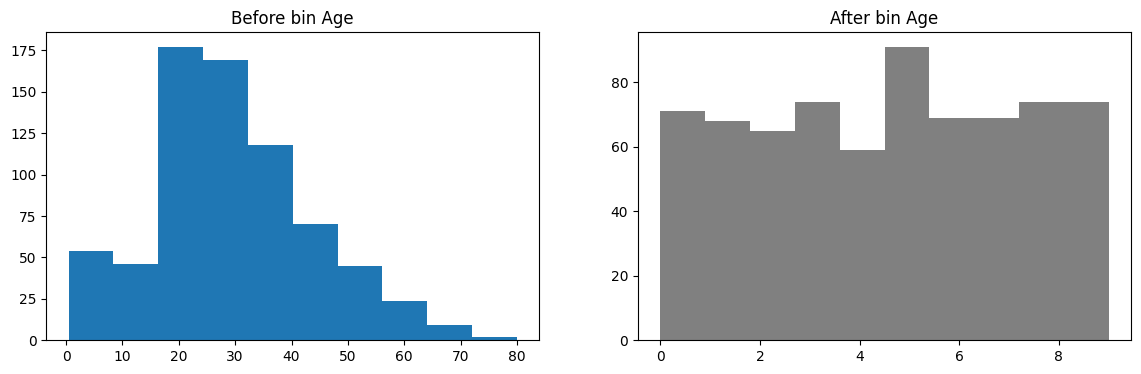

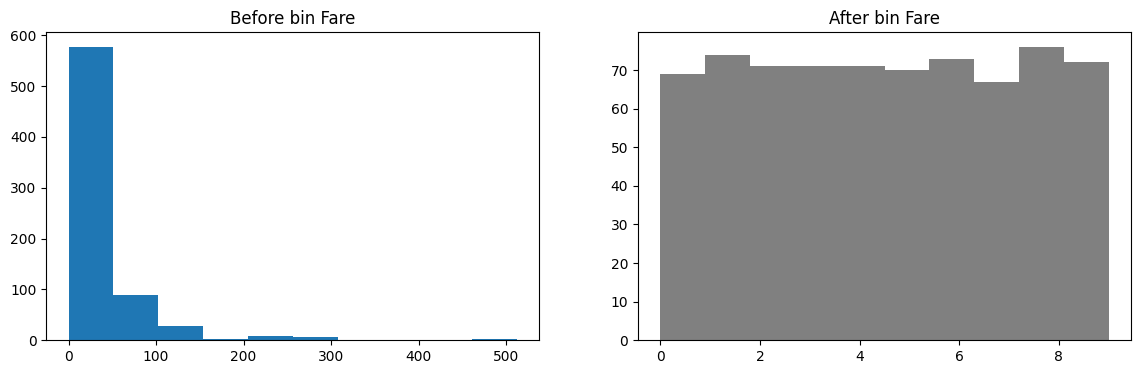

In [83]:
discretize(10,'quantile')

0.6864632237871675


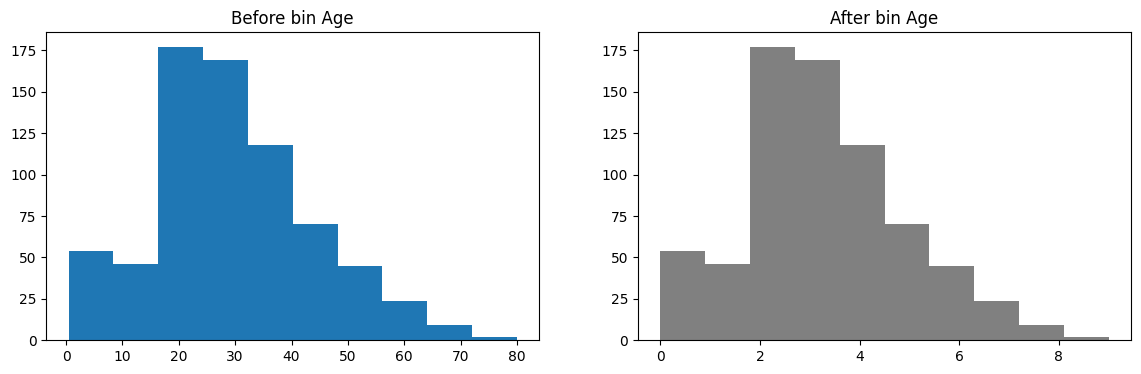

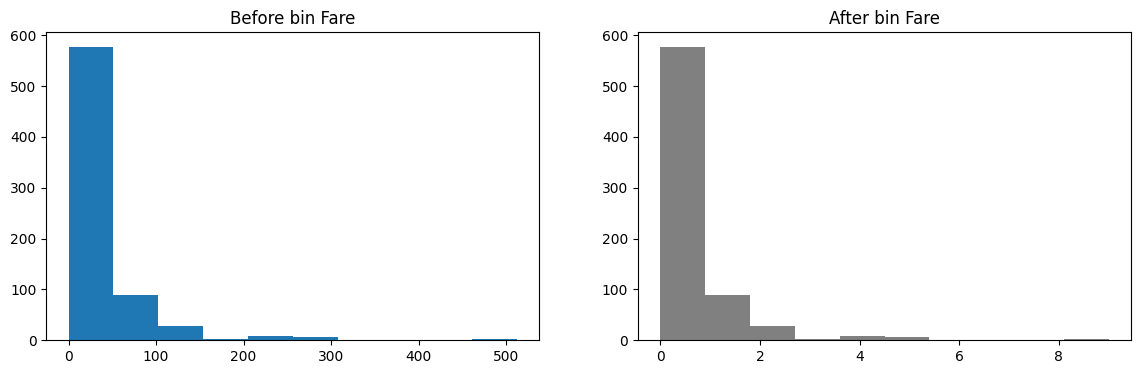

In [84]:
discretize(10,'uniform')

0.6584702660406886


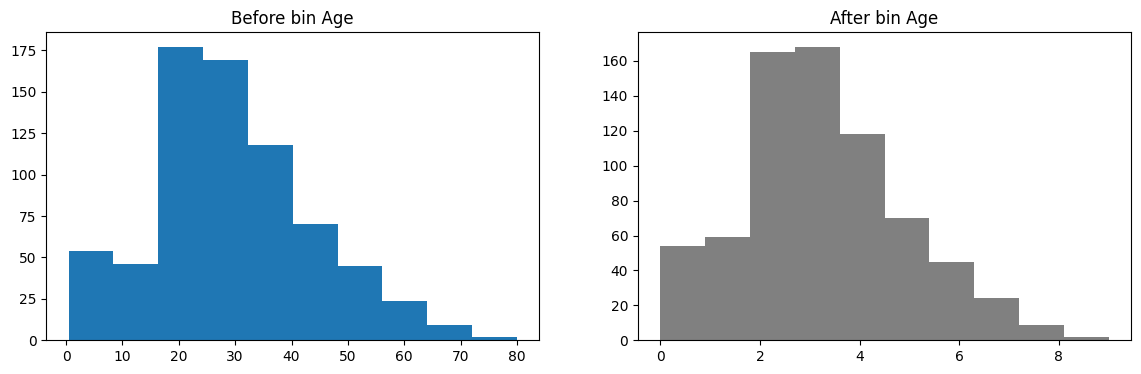

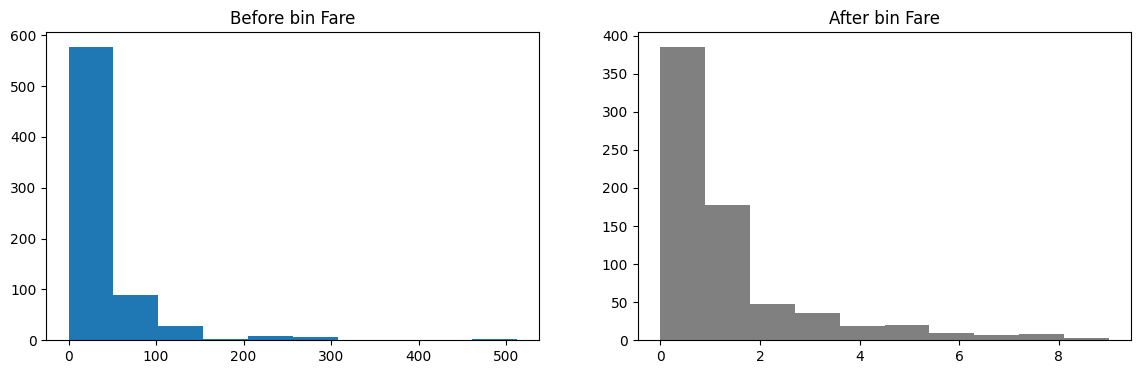

In [85]:
discretize(10,'kmeans')